Ссылка на репозиторий
https://github.com/SergKudahev/RL_HW6_Kudashev

### 2. Сбор оффлайн-датасета RL

In [7]:
!python train_and_collect_data.py --env velocity_cartpole --train_timesteps 300000 --num_trajectories 100 --reward_threshold 475

Using optimized parameters for velocity_cartpole
Training recurrent PPO agent ignoring existing checkpoint on velocity_cartpole for 300000 timesteps...
Episode 1, reward: 27.00, avg_reward (last 50): 27.00, timesteps: 27/300000
New best model saved with reward: 27.0
Episode 2, reward: 10.00, avg_reward (last 50): 18.50, timesteps: 37/300000
Episode 3, reward: 23.00, avg_reward (last 50): 20.00, timesteps: 60/300000
Episode 4, reward: 15.00, avg_reward (last 50): 18.75, timesteps: 75/300000
Episode 5, reward: 20.00, avg_reward (last 50): 19.00, timesteps: 95/300000
Episode 6, reward: 19.00, avg_reward (last 50): 19.00, timesteps: 114/300000
Episode 7, reward: 13.00, avg_reward (last 50): 18.14, timesteps: 127/300000
Episode 8, reward: 17.00, avg_reward (last 50): 18.00, timesteps: 144/300000
Episode 9, reward: 28.00, avg_reward (last 50): 19.11, timesteps: 172/300000
New best model saved with reward: 28.0
Episode 10, reward: 13.00, avg_reward (last 50): 18.50, timesteps: 185/300000
Epis

`Выучили - собрали`

In [8]:
!python utils/visualize_ppo_agent.py --env velocity_cartpole --model_path pomdp_datasets/velocity_cartpole/recurrent_ppo_velocity_cartpole.pt --rnn_type gru

Visualization of velocity_cartpole from pomdp_datasets/velocity_cartpole/recurrent_ppo_velocity_cartpole.pt
RNN type: gru, Hidden dim: 128

Episode 1/5
Step 1: Action=1, Value=73.257
Step 2: Action=1, Value=75.114
Step 3: Action=1, Value=74.912
Step 4: Action=1, Value=74.190
Step 5: Action=0, Value=74.243
Step 6: Action=1, Value=74.401
Step 7: Action=1, Value=74.397
Step 8: Action=0, Value=74.402
Step 9: Action=0, Value=74.225
Step 10: Action=0, Value=74.033
Step 11: Action=0, Value=73.961
Step 12: Action=0, Value=73.999
Step 13: Action=0, Value=74.144
Step 14: Action=0, Value=74.409
Step 15: Action=0, Value=74.780
Step 16: Action=0, Value=75.201
Step 17: Action=0, Value=75.593
Step 18: Action=0, Value=75.890
Step 19: Action=0, Value=76.073
Step 20: Action=0, Value=76.167
Step 21: Action=1, Value=76.207
Step 22: Action=1, Value=76.217
Step 23: Action=1, Value=76.217
Step 24: Action=1, Value=76.214
Step 25: Action=1, Value=76.211
Step 26: Action=1, Value=76.210
Step 27: Action=1, Value=

И ознакомьтесь со статистикой датасета:

In [9]:
!python memory_dt.py --dataset pomdp_datasets/velocity_cartpole --stats_only

Analyzing 100 trajectories files in pomdp_datasets/velocity_cartpole
100%|███████████████████████████████████████| 100/100 [00:00<00:00, 4450.19it/s]

Dataset statistics:
Total episodes: 100
Total steps: 49799
Mean reward per episode: 497.99
Median reward per episode: 500.00
Min/Max reward: 477.00/500.00
Reward std: 5.73
Mean episode length: 497.99
Reward percentiles: 
  10%: 490.60
  25%: 500.00
  50%: 500.00
  75%: 500.00
  90%: 500.00
  95%: 500.00
  99%: 500.00
Saved histogram to plots/velocity_cartpole_rewards_histogram.png


`Получилось обучить`

### 3. Decision Transformer с памятью

Сначала обучите и проверьте стандартный Decision Transformer в качестве базовой линии:


In [9]:
# Обучение базового DT
!python run_memory_dt.py --env velocity_cartpole --memory_type none --n_epochs 7 --eval_episodes 20

Training Memory Decision Transformer on velocity_cartpole...
Dataset stats: total=49739, train=44765, val=4974, state_dim=2, actions=2
Epoch 1/7 [Train]: 100%|█| 700/700 [00:09<00:00, 71.26it/s, loss=0.3539, avg_los
Epoch 1/7: Train Loss=0.4764, Val Loss=0.3829
Running environment validation...
Episode 1: Return=10.0, Steps=10
Episode 2: Return=13.0, Steps=13
Episode 3: Return=11.0, Steps=11
Episode 4: Return=10.0, Steps=10
Episode 5: Return=11.0, Steps=11
Episode 6: Return=11.0, Steps=11
Episode 7: Return=29.0, Steps=29
Episode 8: Return=11.0, Steps=11
Episode 9: Return=45.0, Steps=45
Episode 10: Return=10.0, Steps=10
Validation: Mean Return=16.10, Success Rate=0.00%
New best model with return 16.10
Epoch 2/7 [Train]: 100%|█| 700/700 [00:09<00:00, 71.51it/s, loss=0.3952, avg_los
Epoch 2/7: Train Loss=0.3862, Val Loss=0.3639
Running environment validation...
Episode 1: Return=500.0, Steps=500
Episode 2: Return=176.0, Steps=176
Episode 3: Return=40.0, Steps=40
Episode 4: Return=123.0, S

Добавил в файл обучяения запись статистики, которую потом используем.

График обучения

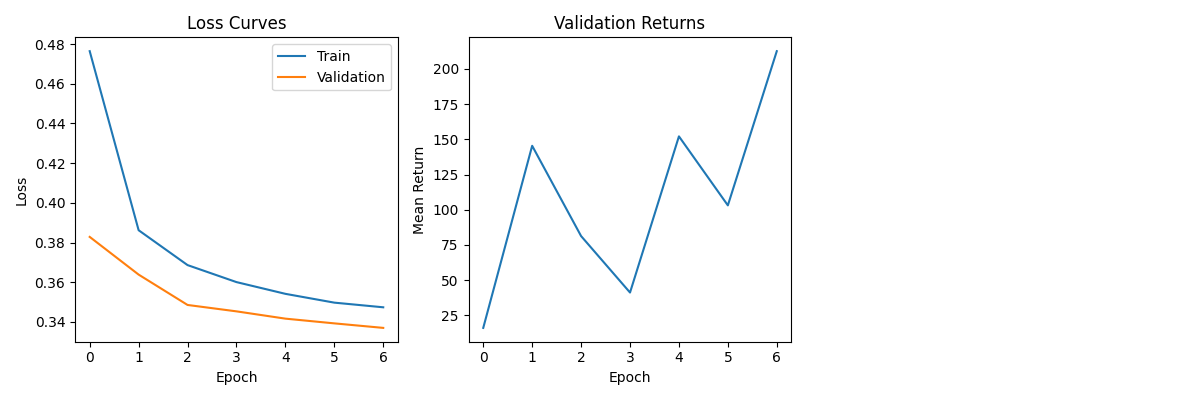

In [10]:
# Проверка базового DT
!python utils/visualize_dt_agent.py --env velocity_cartpole --model_path models/memory_dt_velocity_cartpole_None_best.pt --memory_type none 

Model parameters: n_embed=64, n_layer=3, n_head=4, memory_dim=64
action_head structure: Linear
Visualizing velocity_cartpole agent from models/memory_dt_velocity_cartpole_None_best.pt
Memory type: none, Context length: 20

Episode 1/5
Target return: 500.0
Step 1: Initial action=0 (default)
Step 2: Action=0, RTG=499.00
Step 3: Action=1, RTG=498.00
Step 4: Action=0, RTG=497.00
Step 5: Action=0, RTG=496.00
Step 6: Action=0, RTG=495.00
Step 7: Action=1, RTG=494.00
Step 8: Action=1, RTG=493.00
Step 9: Action=1, RTG=492.00
Step 10: Action=1, RTG=491.00
Step 11: Action=1, RTG=490.00
Step 12: Action=1, RTG=489.00
Step 13: Action=1, RTG=488.00
Step 14: Action=1, RTG=487.00
Step 15: Action=1, RTG=486.00
Step 16: Action=1, RTG=485.00
Step 17: Action=0, RTG=484.00
Step 18: Action=0, RTG=483.00
Step 19: Action=0, RTG=482.00
Step 20: Action=0, RTG=481.00
Step 21: Action=0, RTG=480.00
Step 22: Action=0, RTG=479.00
Step 23: Action=0, RTG=478.00
Step 24: Action=0, RTG=477.00
Step 25: Action=0, RTG=476.

Сохранил данные, для дальнейшего использования в файл:




### Задания

#### Задание 1: Реализация GRU и LSTM памяти (0.2 балла)

Дополните код в `memory_dt.py` для реализации памяти на GRU и LSTM:

Это добавление в `init`

In [ ]:
if memory_type == 'gru':
    print(f"Using GRU memory with {memory_dim} hidden units")
    self.memory = nn.GRU(input_size=n_embed, hidden_size=memory_dim, num_layers=1, batch_first=True)
    self.memory_proj = nn.Linear(memory_dim, n_embed)
elif memory_type == 'lstm':
    print(f"Using LSTM memory with {memory_dim} hidden units")
    self.memory = nn.LSTM(input_size=n_embed, hidden_size=memory_dim, num_layers=1, batch_first=True)
    self.memory_proj = nn.Linear(memory_dim, n_embed)

Это добавление в `forward`

In [ ]:
if self.memory_type == 'gru':
   if self.hidden_state is None:
      # (num_layers, batch, hidden_size)
      h0 = torch.zeros(1, batch_size, self.memory.hidden_size, device=state_embeddings.device)
   else:
      h0 = self.hidden_state
   memory_out, hn = self.memory(state_embeddings, h0)
   self.hidden_state = hn.detach()

elif self.memory_type == 'lstm':
   if self.hidden_state is None:
      # (num_layers, batch, hidden_size)
      h0 = torch.zeros(1, batch_size, self.memory.hidden_size, device=state_embeddings.device)
      c0 = torch.zeros(1, batch_size, self.memory.hidden_size, device=state_embeddings.device)
   else:
      h0, c0 = self.hidden_state
   memory_out, (hn, cn) = self.memory(state_embeddings, (h0, c0))
   self.hidden_state = (hn.detach(), cn.detach())

# project memory to embedding dimension
memory_embedding = self.memory_proj(memory_out)

# combine memory with state embeddings
state_embeddings = state_embeddings + memory_embedding

После реализации модулей памяти обучите улучшенные модели:

In [11]:
# Обучение DT+GRU (0.1 балла)
!python run_memory_dt.py --env velocity_cartpole --memory_type gru --n_epochs 7 --eval_episodes 20

Training Memory Decision Transformer on velocity_cartpole...
Dataset stats: total=49739, train=44765, val=4974, state_dim=2, actions=2
Using GRU memory with 64 hidden units
Epoch 1/7 [Train]: 100%|█| 700/700 [00:10<00:00, 67.60it/s, loss=0.3957, avg_los
Epoch 1/7: Train Loss=0.4559, Val Loss=0.3608
Running environment validation...
Episode 1: Return=500.0, Steps=500
Episode 2: Return=14.0, Steps=14
Episode 3: Return=15.0, Steps=15
Episode 4: Return=500.0, Steps=500
Episode 5: Return=500.0, Steps=500
Episode 6: Return=15.0, Steps=15
Episode 7: Return=16.0, Steps=16
Episode 8: Return=500.0, Steps=500
Episode 9: Return=15.0, Steps=15
Episode 10: Return=16.0, Steps=16
Validation: Mean Return=209.10, Success Rate=40.00%
New best model with return 209.10
Epoch 2/7 [Train]: 100%|█| 700/700 [00:10<00:00, 69.11it/s, loss=0.3539, avg_los
Epoch 2/7: Train Loss=0.3628, Val Loss=0.3453
Running environment validation...
Episode 1: Return=500.0, Steps=500
Episode 2: Return=500.0, Steps=500
Episode 3:

График обучения

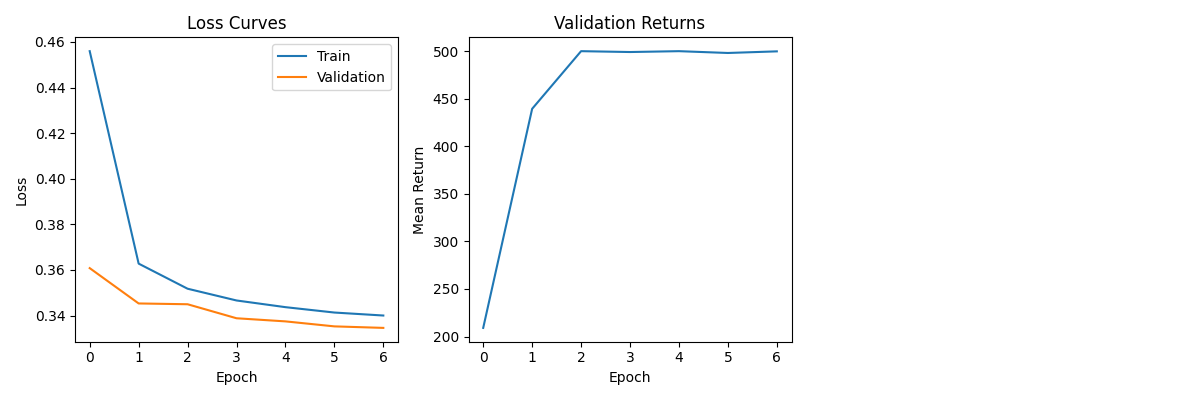

In [12]:
# Обучение DT+LSTM (0.1 балла)
!python run_memory_dt.py --env velocity_cartpole --memory_type lstm --n_epochs 7 --eval_episodes 20

Training Memory Decision Transformer on velocity_cartpole...
Dataset stats: total=49739, train=44765, val=4974, state_dim=2, actions=2
Using LSTM memory with 64 hidden units
Epoch 1/7 [Train]: 100%|█| 700/700 [00:10<00:00, 67.04it/s, loss=0.3423, avg_los
Epoch 1/7: Train Loss=0.4492, Val Loss=0.3735
Running environment validation...
Episode 1: Return=500.0, Steps=500
Episode 2: Return=500.0, Steps=500
Episode 3: Return=500.0, Steps=500
Episode 4: Return=500.0, Steps=500
Episode 5: Return=500.0, Steps=500
Episode 6: Return=500.0, Steps=500
Episode 7: Return=500.0, Steps=500
Episode 8: Return=500.0, Steps=500
Episode 9: Return=500.0, Steps=500
Episode 10: Return=500.0, Steps=500
Validation: Mean Return=500.00, Success Rate=100.00%
New best model with return 500.00
Epoch 2/7 [Train]: 100%|█| 700/700 [00:10<00:00, 69.07it/s, loss=0.3529, avg_los
Epoch 2/7: Train Loss=0.3634, Val Loss=0.3498
Running environment validation...
Episode 1: Return=500.0, Steps=500
Episode 2: Return=500.0, Steps=

График обучения
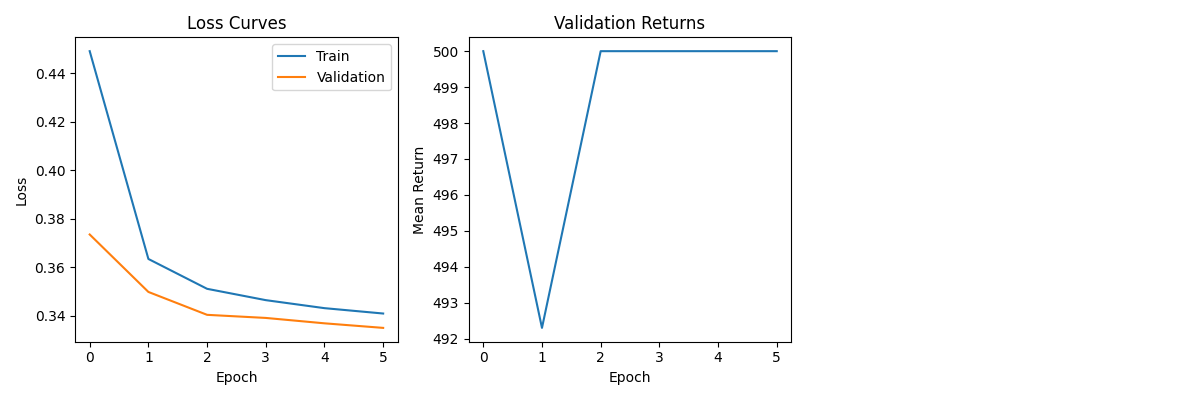

Проверьте их производительность:

In [13]:
# Проверка DT+GRU
!python utils/visualize_dt_agent.py --env velocity_cartpole --model_path models/memory_dt_velocity_cartpole_gru_best.pt --memory_type gru 

Model parameters: n_embed=64, n_layer=3, n_head=4, memory_dim=64
action_head structure: Linear
Using GRU memory with 64 hidden units
Visualizing velocity_cartpole agent from models/memory_dt_velocity_cartpole_gru_best.pt
Memory type: gru, Context length: 20

Episode 1/5
Target return: 500.0
Step 1: Initial action=0 (default)
Step 2: Action=0, RTG=499.00
Step 3: Action=1, RTG=498.00
Step 4: Action=1, RTG=497.00
Step 5: Action=1, RTG=496.00
Step 6: Action=1, RTG=495.00
Step 7: Action=1, RTG=494.00
Step 8: Action=0, RTG=493.00
Step 9: Action=0, RTG=492.00
Step 10: Action=0, RTG=491.00
Step 11: Action=0, RTG=490.00
Step 12: Action=0, RTG=489.00
Step 13: Action=0, RTG=488.00
Step 14: Action=0, RTG=487.00
Step 15: Action=0, RTG=486.00
Step 16: Action=1, RTG=485.00
Step 17: Action=1, RTG=484.00
Step 18: Action=1, RTG=483.00
Step 19: Action=1, RTG=482.00
Step 20: Action=1, RTG=481.00
Step 21: Action=1, RTG=480.00
Step 22: Action=1, RTG=479.00
Step 23: Action=1, RTG=478.00
Step 24: Action=0, RT

In [14]:
# Проверка DT+LSTM
!python utils/visualize_dt_agent.py --env velocity_cartpole --model_path models/memory_dt_velocity_cartpole_lstm_best.pt --memory_type lstm 

Model parameters: n_embed=64, n_layer=3, n_head=4, memory_dim=64
action_head structure: Linear
Using LSTM memory with 64 hidden units
Visualizing velocity_cartpole agent from models/memory_dt_velocity_cartpole_lstm_best.pt
Memory type: lstm, Context length: 20

Episode 1/5
Target return: 500.0
Step 1: Initial action=0 (default)
Step 2: Action=0, RTG=499.00
Step 3: Action=1, RTG=498.00
Step 4: Action=1, RTG=497.00
Step 5: Action=1, RTG=496.00
Step 6: Action=1, RTG=495.00
Step 7: Action=1, RTG=494.00
Step 8: Action=1, RTG=493.00
Step 9: Action=0, RTG=492.00
Step 10: Action=0, RTG=491.00
Step 11: Action=0, RTG=490.00
Step 12: Action=0, RTG=489.00
Step 13: Action=0, RTG=488.00
Step 14: Action=0, RTG=487.00
Step 15: Action=0, RTG=486.00
Step 16: Action=0, RTG=485.00
Step 17: Action=0, RTG=484.00
Step 18: Action=1, RTG=483.00
Step 19: Action=1, RTG=482.00
Step 20: Action=1, RTG=481.00
Step 21: Action=1, RTG=480.00
Step 22: Action=1, RTG=479.00
Step 23: Action=1, RTG=478.00
Step 24: Action=1,

#### Задание 3: Собственный механизм памяти (0.3 балла)



Реализация памяти просто через вектор и полносвязанные слои


In [ ]:
elif memory_type == 'mlp_vector':
print(f"Using MLP memory with {memory_dim} hidden units")
self.memory = None
self.memory_dim = memory_dim
self.memory_vector = nn.Parameter(torch.zeros(1, memory_dim))
self.memory_update = nn.Sequential(
    nn.Linear(n_embed + memory_dim, memory_dim),
    nn.Tanh(),
    nn.Linear(memory_dim, memory_dim),
    nn.Tanh()
)
self.memory_proj = nn.Linear(memory_dim, n_embed)

...

if self.memory_type == 'mlp_vector':
    if not hasattr(self, 'current_memory') or self.current_memory is None:
        memory = self.memory_vector.expand(batch_size, -1).clone()
    else:
        memory = self.current_memory

    memory_vectors = []
    for t in range(seq_length):
        inp = torch.cat([state_embeddings[:, t, :], memory], dim=-1)
        memory = self.memory_update(inp)
        memory_vectors.append(memory.unsqueeze(1))
    memory_vectors = torch.cat(memory_vectors, dim=1)  # [B, seq, memory_dim]
    self.current_memory = memory.detach()
    memory_embedding = self.memory_proj(memory_vectors)
    # state_embeddings = state_embeddings + memory_embedding
    action_embeddings = action_embeddings + memory_embedding

Попробовал два варианта - добавлять память к состоянию и к действиям.

Если добавлять к действиям - результат плохой (что очевидно)

Если к состояниям - все хорошо

In [ ]:
state_embeddings = state_embeddings + memory_embedding
...
action_embeddings = action_embeddings + memory_embedding

In [16]:
# К действиям
!python run_memory_dt.py --env velocity_cartpole --memory_type mlp_vector --n_epochs 7 --eval_episodes 20

Training Memory Decision Transformer on velocity_cartpole...
Dataset stats: total=49739, train=44765, val=4974, state_dim=2, actions=2
Using MLP memory with 64 hidden units
Epoch 1/7 [Train]: 100%|█| 700/700 [00:13<00:00, 50.88it/s, loss=0.4027, avg_los
Epoch 1/7: Train Loss=0.4800, Val Loss=0.3861
Running environment validation...
Episode 1: Return=53.0, Steps=53
Episode 2: Return=11.0, Steps=11
Episode 3: Return=55.0, Steps=55
Episode 4: Return=58.0, Steps=58
Episode 5: Return=54.0, Steps=54
Episode 6: Return=29.0, Steps=29
Episode 7: Return=59.0, Steps=59
Episode 8: Return=15.0, Steps=15
Episode 9: Return=11.0, Steps=11
Episode 10: Return=60.0, Steps=60
Validation: Mean Return=40.50, Success Rate=0.00%
New best model with return 40.50
Epoch 2/7 [Train]: 100%|█| 700/700 [00:13<00:00, 51.99it/s, loss=0.4009, avg_los
Epoch 2/7: Train Loss=0.3922, Val Loss=0.3747
Running environment validation...
Episode 1: Return=26.0, Steps=26
Episode 2: Return=26.0, Steps=26
Episode 3: Return=57.0, S

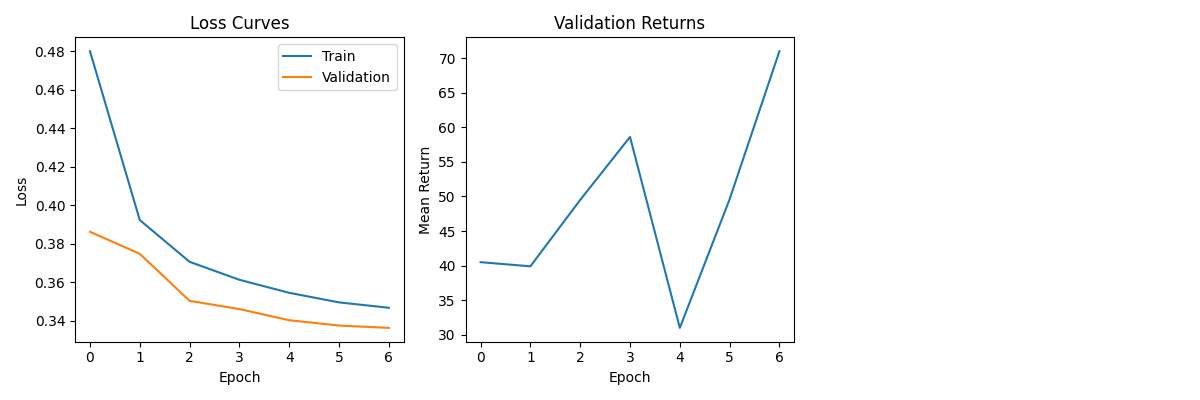

In [17]:
# К cостояниям
!python run_memory_dt.py --env velocity_cartpole --memory_type mlp_vector --n_epochs 7 --eval_episodes 20

Training Memory Decision Transformer on velocity_cartpole...
Dataset stats: total=49739, train=44765, val=4974, state_dim=2, actions=2
Using MLP memory with 64 hidden units
Epoch 1/7 [Train]: 100%|█| 700/700 [00:14<00:00, 49.71it/s, loss=0.3146, avg_los
Epoch 1/7: Train Loss=0.4684, Val Loss=0.3584
Running environment validation...
Episode 1: Return=476.0, Steps=476
Episode 2: Return=372.0, Steps=372
Episode 3: Return=143.0, Steps=143
Episode 4: Return=500.0, Steps=500
Episode 5: Return=500.0, Steps=500
Episode 6: Return=500.0, Steps=500
Episode 7: Return=500.0, Steps=500
Episode 8: Return=500.0, Steps=500
Episode 9: Return=500.0, Steps=500
Episode 10: Return=398.0, Steps=398
Validation: Mean Return=438.90, Success Rate=70.00%
New best model with return 438.90
Epoch 2/7 [Train]: 100%|█| 700/700 [00:13<00:00, 50.72it/s, loss=0.2998, avg_los
Epoch 2/7: Train Loss=0.3539, Val Loss=0.3451
Running environment validation...
Episode 1: Return=500.0, Steps=500
Episode 2: Return=500.0, Steps=50

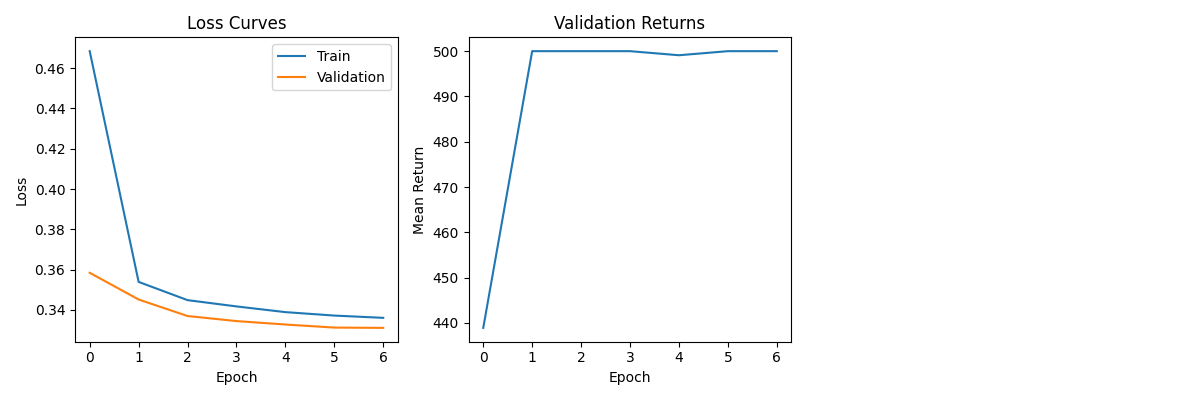

In [18]:
!python utils/visualize_dt_agent.py --env velocity_cartpole --model_path models/memory_dt_velocity_cartpole_mlp_vector_best.pt --memory_type mlp_vector 

Model parameters: n_embed=64, n_layer=3, n_head=4, memory_dim=64
action_head structure: Linear
Using MLP memory with 64 hidden units
Visualizing velocity_cartpole agent from models/memory_dt_velocity_cartpole_mlp_vector_best.pt
Memory type: mlp_vector, Context length: 20

Episode 1/5
Target return: 500.0
Step 1: Initial action=0 (default)
Step 2: Action=1, RTG=499.00
Step 3: Action=1, RTG=498.00
Step 4: Action=1, RTG=497.00
Step 5: Action=0, RTG=496.00
Step 6: Action=0, RTG=495.00
Step 7: Action=0, RTG=494.00
Step 8: Action=1, RTG=493.00
Step 9: Action=1, RTG=492.00
Step 10: Action=1, RTG=491.00
Step 11: Action=0, RTG=490.00
Step 12: Action=0, RTG=489.00
Step 13: Action=0, RTG=488.00
Step 14: Action=0, RTG=487.00
Step 15: Action=0, RTG=486.00
Step 16: Action=1, RTG=485.00
Step 17: Action=1, RTG=484.00
Step 18: Action=1, RTG=483.00
Step 19: Action=1, RTG=482.00
Step 20: Action=1, RTG=481.00
Step 21: Action=1, RTG=480.00
Step 22: Action=0, RTG=479.00
Step 23: Action=0, RTG=478.00
Step 24

#### Задание 2: Сравнительный анализ (0.3 балла)


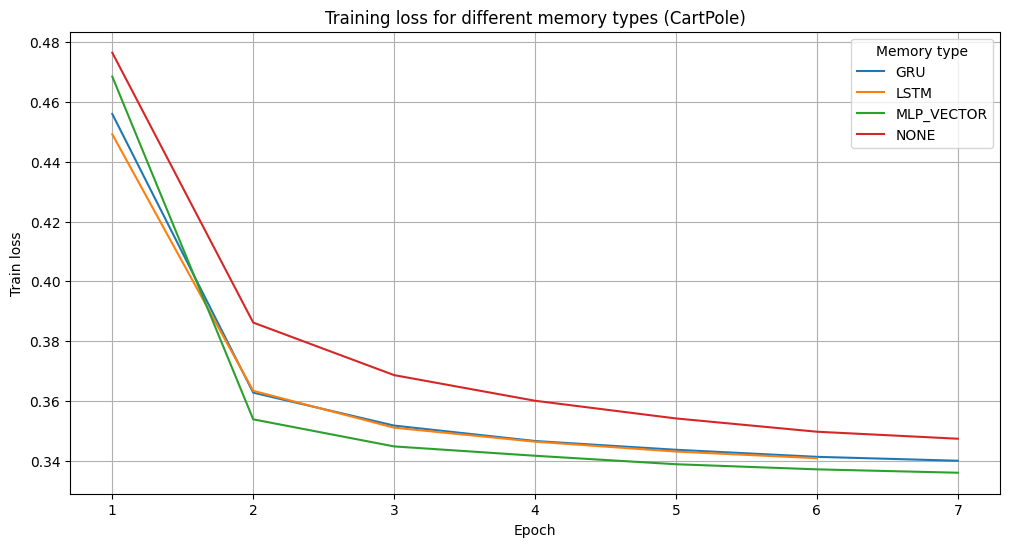

In [22]:
train_logs = [
    'results/velocity_cartpole_dt_gru_trainlog.csv', 
    'results/velocity_cartpole_dt_lstm_trainlog.csv', 
    'results/velocity_cartpole_dt_mlp_vector_trainlog.csv',
    'results/velocity_cartpole_dt_None_trainlog.csv'
]

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.figure(figsize=(12, 6))
for log in train_logs:
    if os.path.exists(log):
        df = pd.read_csv(log)
        label = log.split('/')[-1].replace('velocity_cartpole_dt_', '').replace('_trainlog.csv', '').upper()
        sns.lineplot(data=df, x='epoch', y='train_loss', label=label)
    else:
        print(f"Log file {log} does not exist.")

plt.title("Training loss for different memory types (CartPole)")
plt.xlabel('Epoch')
plt.ylabel('Train loss')
plt.grid()
plt.legend(title="Memory type")
plt.show()

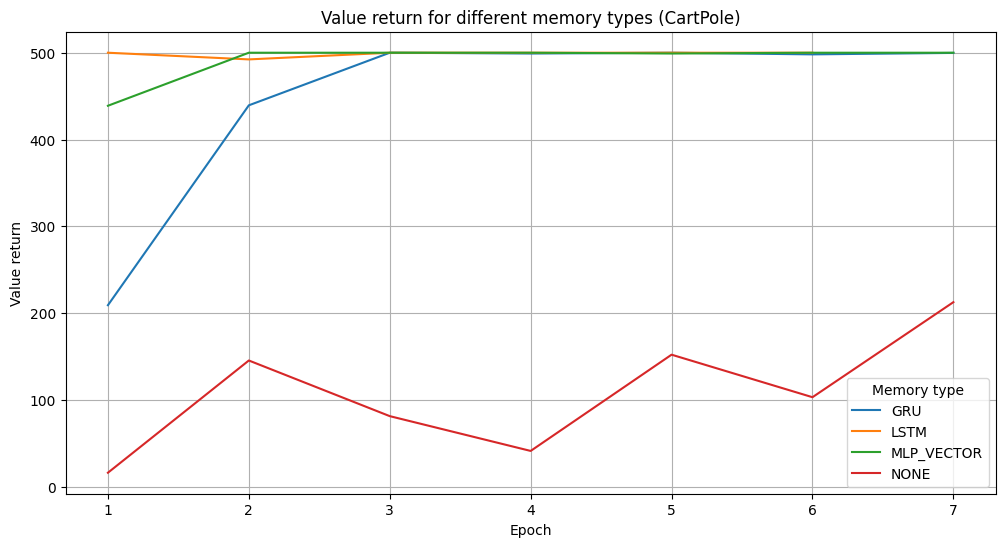

In [24]:
plt.figure(figsize=(12, 6))
for log in train_logs:
    if os.path.exists(log):
        df = pd.read_csv(log)
        label = log.split('/')[-1].replace('velocity_cartpole_dt_', '').replace('_trainlog.csv', '').upper()
        sns.lineplot(data=df, x='epoch', y='val_return', label=label)
    else:
        print(f"Log file {log} does not exist.")

plt.title("Value return for different memory types (CartPole)")
plt.xlabel('Epoch')
plt.ylabel('Value return')
plt.grid()
plt.legend(title="Memory type")
plt.show()

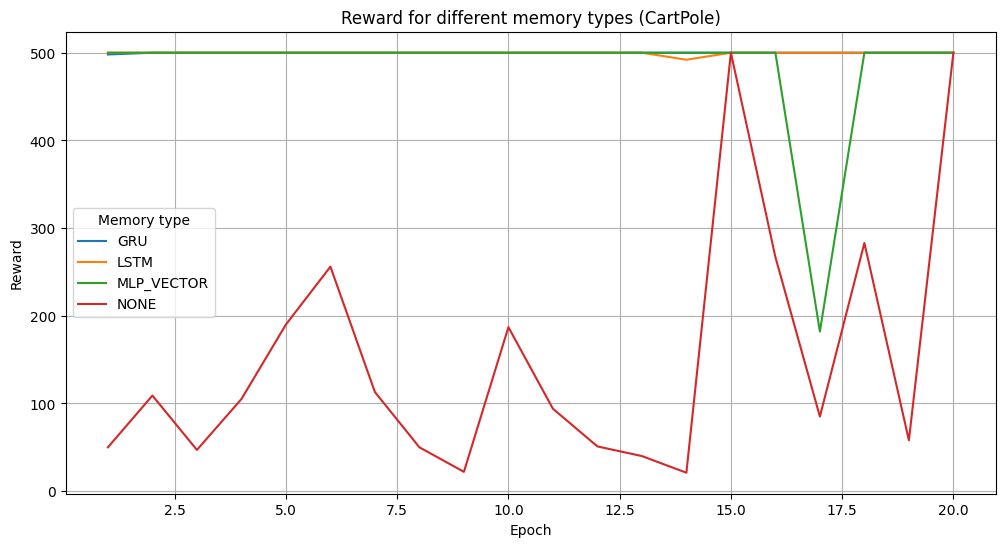

In [28]:
train_logs = [
    'results/velocity_cartpole_dt_gru_eval_rewards.csv', 
    'results/velocity_cartpole_dt_lstm_eval_rewards.csv',
    'results/velocity_cartpole_dt_mlp_vector_eval_rewards.csv',
    'results/velocity_cartpole_dt_None_eval_rewards.csv'
    
]

plt.figure(figsize=(12, 6))
for log in train_logs:
    if os.path.exists(log):
        df = pd.read_csv(log)
        label = log.split('/')[-1].replace('velocity_cartpole_dt_', '').replace('_eval_rewards.csv', '').upper()
        sns.lineplot(data=df, x='episode', y='reward', label=label)
    else:
        print(f"Log file {log} does not exist.")

plt.title("Reward for different memory types (CartPole)")
plt.xlabel('Epoch')
plt.ylabel('Reward')
plt.grid()
plt.legend(title="Memory type")
plt.show()

Очевидно, что добавление памяти существенно улучшает результат.

Разные варианты памяти дают похожие скоры, близкие к максимому - наверное потому, что модель достаточно простая.

Добавление памяти только к действиям, без памяти к состояниям только ухудшает резульат. В целом, это очевидно, так как действие является результатом состояния.